In [2]:
import os
import csv
import copy
import torch
import numpy as np
import pandas as pd
import tensorflow as tf
import seaborn as sns # type: ignore
import missingno as msno # type: ignore
import matplotlib.pyplot as plt
import torch.nn.init as init
import torch.nn.functional as F
import tensorflow.keras.layers as L # type: ignore
from torch import nn
from torch.autograd import Variable
from scipy import interpolate
from keras import backend as K
from tensorflow.keras.models import Sequential # type: ignore
from tensorflow.keras.optimizers import SGD, Adam # type: ignore
from tensorflow.keras.callbacks import EarlyStopping # type: ignore
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import f1_score, r2_score, mean_absolute_error, mean_squared_error, mean_squared_log_error
from ydata_synthetic.synthesizers import ModelParameters, TrainParameters # type: ignore
from ydata_synthetic.synthesizers.timeseries import TimeSeriesSynthesizer # type: ignore

In [2]:
user_contacted_healthcare_file1 = pd.read_csv("data/data_raw/copd/9_23_22/adjudicated_exacs.csv")
user_contacted_healthcare_file1

,SID,excerb_first_cntct_hlthcr
0,KNI32C,407
1,KNI32C,376
2,98RIV7,292
3,98RIV7,205
4,WGQFML,328
5,MMOGWL,271
6,MMOGWL,78
7,PYW9OA,225
8,PYW9OA,44
9,JC7WX8,222


In [3]:
user_contacted_healthcare_file2 = pd.read_csv("data/data_raw/copd/12_13_2021/adjudicated_exacs.csv")
user_contacted_healthcare_file2 = user_contacted_healthcare_file2[["SID", "excerb_start"]]
user_contacted_healthcare_file2.columns = user_contacted_healthcare_file2.columns.str.replace("excerb_start", "excerb_first_cntct_hlthcr")
user_contacted_healthcare_file2

,SID,excerb_first_cntct_hlthcr
0,87F308,254
1,D2138D,163
2,D2138D,26
3,D52ABA,291
4,D52ABA,103
5,F5615E,222
6,F5615E,42
7,6877C6,118
8,6877C6,188
9,6877C6,33


In [4]:
user_contacted_healthcare_data = pd.concat([user_contacted_healthcare_file1, user_contacted_healthcare_file2])
user_contacted_healthcare_data

,SID,excerb_first_cntct_hlthcr
0,KNI32C,407
1,KNI32C,376
2,98RIV7,292
3,98RIV7,205
4,WGQFML,328
5,MMOGWL,271
6,MMOGWL,78
7,PYW9OA,225
8,PYW9OA,44
9,JC7WX8,222


In [5]:
survey_file1 = pd.read_csv("data/data_raw/copd/9_23_22/survey_data.csv")
survey_file2 = pd.read_csv("data/data_raw/copd/12_13_2021/survey_data.csv")
survey_data = pd.concat([survey_file1, survey_file2])
survey_data

,SID,study_day,exact_computed,avg_ox_sat,BASE,MOV,EVENT,ROLLAVG,DURATION,TOTONSET,BASELINE
0,36Z7KP,0,25.0,NaN,NaN,NaN,NaN,NaN,NaN,3.0,START
1,36Z7KP,1,25.0,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN
2,36Z7KP,2,25.0,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN
3,36Z7KP,3,25.0,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN
4,36Z7KP,4,25.0,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
4975,277705,131,52.0,91.0,33.666667,48.666667,NaN,50.666667,NaN,2.0,NaN
4976,277705,132,48.0,91.0,33.666667,48.666667,NaN,47.000000,NaN,2.0,NaN
4977,277705,133,41.0,91.0,33.666667,48.666667,NaN,44.000000,NaN,2.0,NaN
4978,277705,134,43.0,91.0,33.666667,48.666667,NaN,40.000000,NaN,2.0,NaN


In [6]:
inhaler_file1 = pd.read_csv("data/data_raw/copd/9_23_22/inhaler_usage.csv")
inhaler_file2 = pd.read_csv("data/data_raw/copd/12_13_2021/inhaler_data.csv")
inhaler_data = pd.concat([inhaler_file1, inhaler_file2])
inhaler_data = inhaler_data.groupby(["SID","study_day","medication_type"])["puffs"].sum().reset_index()
inhaler_data

,SID,study_day,medication_type,puffs
0,022239,15,rescue,1
1,022239,16,rescue,4
2,022239,17,rescue,1
3,022239,18,rescue,1
4,022239,23,rescue,1
...,...,...,...,...
16893,XY827R,226,controller,2
16894,XY827R,226,rescue,2
16895,XY827R,227,controller,2
16896,XY827R,227,rescue,6


In [7]:
# we want to use patients who have contacted healthcare at least twice or more in a year
healthcare_contact_counts = user_contacted_healthcare_data.groupby(['SID']).size()
user_ids_for_training = healthcare_contact_counts[healthcare_contact_counts >= 2].index
user_ids_for_training = user_ids_for_training.to_numpy()
# user_ids_for_training = ['7RNE74', '98RIV7', 'JC7WX8', 'KNI32C', 'MMOGWL', 'PYW9OA', 'WGQFML', 'XKCKIT']

In [8]:
feature_columns_for_survey = ["SID","study_day","exact_computed","avg_ox_sat"]
survey_features = survey_data[feature_columns_for_survey]
survey_features_for_selected_users = survey_features[survey_features["SID"].isin(user_ids_for_training)]
survey_features_for_selected_users

,SID,study_day,exact_computed,avg_ox_sat
1667,7RNE74,0,36.0,NaN
1668,7RNE74,1,36.0,NaN
1669,7RNE74,2,36.0,NaN
1670,7RNE74,3,NaN,NaN
1671,7RNE74,4,36.0,NaN
...,...,...,...,...
4766,6877C6,360,37.0,93.0
4767,6877C6,361,37.0,96.0
4768,6877C6,362,37.0,92.0
4769,6877C6,363,37.0,94.0


In [9]:
# combine survey and inhaler data
survey_features_for_selected_users["index"] = survey_features_for_selected_users.index
survey_features_for_selected_users_with_medication = survey_features_for_selected_users.merge(inhaler_data[inhaler_data["medication_type"]=='rescue'], how="left", on=["SID","study_day"]).set_index("index")
survey_features_for_selected_users_with_medication["index"] = survey_features_for_selected_users_with_medication.index
survey_features_for_selected_users_with_medication = survey_features_for_selected_users_with_medication.merge(inhaler_data[inhaler_data["medication_type"]=='controller'], how="left", on=["SID","study_day"]).set_index("index")

# update column names
survey_features_for_selected_users_with_medication.columns = survey_features_for_selected_users_with_medication.columns.str.replace('puffs_x', 'rescue')
survey_features_for_selected_users_with_medication.columns = survey_features_for_selected_users_with_medication.columns.str.replace('puffs_y', 'controller')
survey_features_for_selected_users_with_medication.columns = survey_features_for_selected_users_with_medication.columns.str.replace('SID', 'id')

survey_features_for_selected_users_with_medication.fillna(value={"rescue": 0}, inplace=True)
survey_features_for_selected_users_with_medication.fillna(value={"controller": 0}, inplace=True)
survey_features_for_selected_users_with_medication

/var/folders/fr/kmsxy0_d0mx6vk150t1r8j_r0000gq/T/ipykernel_84950/2306503184.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  survey_features_for_selected_users["index"] = survey_features_for_selected_users.index


,id,study_day,exact_computed,avg_ox_sat,medication_type_x,rescue,medication_type_y,controller
index,,,,,,,,
1667,7RNE74,0,36.0,NaN,rescue,2.0,NaN,0.0
1668,7RNE74,1,36.0,NaN,rescue,2.0,NaN,0.0
1669,7RNE74,2,36.0,NaN,rescue,2.0,NaN,0.0
1670,7RNE74,3,NaN,NaN,rescue,2.0,NaN,0.0
1671,7RNE74,4,36.0,NaN,rescue,2.0,NaN,0.0
...,...,...,...,...,...,...,...,...
4766,6877C6,360,37.0,93.0,rescue,2.0,controller,1.0
4767,6877C6,361,37.0,96.0,rescue,2.0,controller,1.0
4768,6877C6,362,37.0,92.0,rescue,4.0,controller,1.0


In [10]:
fitbit_file1 = pd.read_csv("data/data_raw/copd/9_23_22/fitbit_data.csv.tar.gz")
fitbit_file2 = pd.read_csv("data/data_raw/copd/12_13_2021/fitbit_data.csv.zip")
fitbit_column_names = {'fitbit_data.csv': 'SID', 'Value': 'heart_rate', 'Calories': 'calories', 'Steps' : 'steps'}
fitbit_file1.rename(columns=fitbit_column_names, inplace=True)
fitbit_data = pd.concat([fitbit_file1, fitbit_file2])
fitbit_data.rename(columns={'SID': 'id', 'Value' : 'heart_rate'}, inplace=True)
fitbit_data

/var/folders/fr/kmsxy0_d0mx6vk150t1r8j_r0000gq/T/ipykernel_84950/2078206754.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  fitbit_file2 = pd.read_csv("data/data_raw/copd/12_13_2021/fitbit_data.csv.zip")


,id,study_day,study_hour,study_minute,heart_rate,steps,calories
0,36Z7KP,57,0,0,NaN,0.0,1.12950
1,36Z7KP,57,0,1,NaN,0.0,1.12950
2,36Z7KP,57,0,2,NaN,0.0,1.12950
3,36Z7KP,57,0,3,NaN,0.0,1.12950
4,36Z7KP,57,0,4,NaN,0.0,1.12950
...,...,...,...,...,...,...,...
7530868,F5615E,366,21,15,NaN,0.0,0.79706
7530869,F5615E,366,21,16,NaN,0.0,0.72460
7530870,F5615E,366,21,17,NaN,0.0,0.72460
7530871,F5615E,366,21,18,NaN,0.0,0.72460


In [11]:
fitbit_data_for_selected_users = fitbit_data[fitbit_data["id"].isin(user_ids_for_training)]
fitbit_data_for_selected_users

,id,study_day,study_hour,study_minute,heart_rate,steps,calories
1641600,7RNE74,0,0,0,77.0,0.0,1.57332
1641601,7RNE74,0,0,1,76.0,0.0,1.57332
1641602,7RNE74,0,0,2,78.0,0.0,1.57332
1641603,7RNE74,0,0,3,80.0,0.0,1.57332
1641604,7RNE74,0,0,4,79.0,0.0,1.70443
...,...,...,...,...,...,...,...
7530868,F5615E,366,21,15,NaN,0.0,0.79706
7530869,F5615E,366,21,16,NaN,0.0,0.72460
7530870,F5615E,366,21,17,NaN,0.0,0.72460
7530871,F5615E,366,21,18,NaN,0.0,0.72460


In [12]:
daily_fitbit_data = fitbit_data_for_selected_users.groupby(["id", "study_day"], as_index=False).mean()
daily_fitbit_data

,id,study_day,study_hour,study_minute,heart_rate,steps,calories
0,6877C6,5,11.5,29.5,88.707355,2.585417,1.832991
1,6877C6,6,11.5,29.5,88.823088,4.632639,2.166502
2,6877C6,7,11.5,29.5,85.447568,3.709028,1.981855
3,6877C6,8,11.5,29.5,84.171528,4.227083,2.062615
4,6877C6,9,11.5,29.5,83.942337,3.548611,1.933599
...,...,...,...,...,...,...,...
4106,PYW9OA,631,11.5,29.5,83.335417,1.506250,0.875457
4107,PYW9OA,632,11.5,29.5,78.702240,0.343056,0.774188
4108,PYW9OA,633,11.5,29.5,78.219178,0.186806,0.742285
4109,PYW9OA,634,11.5,29.5,78.533333,1.727778,0.888929


In [13]:
daily_fitbit_data["study_day"] = daily_fitbit_data["study_day"].astype(int)

In [14]:
all_features = survey_features_for_selected_users_with_medication.merge(daily_fitbit_data, how="left", on=["id", "study_day"])
all_features

,id,study_day,exact_computed,avg_ox_sat,medication_type_x,rescue,medication_type_y,controller,study_hour,study_minute,heart_rate,steps,calories
0,7RNE74,0,36.0,NaN,rescue,2.0,NaN,0.0,11.5,29.5,78.889583,8.281944,2.531425
1,7RNE74,1,36.0,NaN,rescue,2.0,NaN,0.0,11.5,29.5,78.797753,4.203472,2.158763
2,7RNE74,2,36.0,NaN,rescue,2.0,NaN,0.0,11.5,29.5,80.021183,3.747222,2.107229
3,7RNE74,3,NaN,NaN,rescue,2.0,NaN,0.0,11.5,29.5,82.357639,6.442361,2.569483
4,7RNE74,4,36.0,NaN,rescue,2.0,NaN,0.0,11.5,29.5,81.062500,4.215972,2.314365
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4084,6877C6,360,37.0,93.0,rescue,2.0,controller,1.0,11.5,29.5,80.902778,6.665278,2.327797
4085,6877C6,361,37.0,96.0,rescue,2.0,controller,1.0,11.5,29.5,83.907639,6.993056,2.576260
4086,6877C6,362,37.0,92.0,rescue,4.0,controller,1.0,11.5,29.5,82.964583,7.350000,2.557643
4087,6877C6,363,37.0,94.0,NaN,0.0,controller,1.0,11.5,29.5,76.996802,3.434028,1.836592


In [15]:
selected_features = ["id","study_day","exact_computed","avg_ox_sat","rescue","controller","heart_rate","steps","calories"]
all_features = all_features[selected_features]
all_features

,id,study_day,exact_computed,avg_ox_sat,rescue,controller,heart_rate,steps,calories
0,7RNE74,0,36.0,NaN,2.0,0.0,78.889583,8.281944,2.531425
1,7RNE74,1,36.0,NaN,2.0,0.0,78.797753,4.203472,2.158763
2,7RNE74,2,36.0,NaN,2.0,0.0,80.021183,3.747222,2.107229
3,7RNE74,3,NaN,NaN,2.0,0.0,82.357639,6.442361,2.569483
4,7RNE74,4,36.0,NaN,2.0,0.0,81.062500,4.215972,2.314365
...,...,...,...,...,...,...,...,...,...
4084,6877C6,360,37.0,93.0,2.0,1.0,80.902778,6.665278,2.327797
4085,6877C6,361,37.0,96.0,2.0,1.0,83.907639,6.993056,2.576260
4086,6877C6,362,37.0,92.0,4.0,1.0,82.964583,7.350000,2.557643
4087,6877C6,363,37.0,94.0,0.0,1.0,76.996802,3.434028,1.836592


In [16]:
all_features['exacerbation_event'] = 0

for _, row in user_contacted_healthcare_data.iterrows():
    sid = row['SID']
    study_day = row['excerb_first_cntct_hlthcr']

    all_features.loc[(all_features['id'] == sid) & (all_features['study_day'] == study_day), 'exacerbation_event'] = 1

/var/folders/fr/kmsxy0_d0mx6vk150t1r8j_r0000gq/T/ipykernel_84950/2626914217.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_features['exacerbation_event'] = 0


In [17]:
all_features

,id,study_day,exact_computed,avg_ox_sat,rescue,controller,heart_rate,steps,calories,exacerbation_event
0,7RNE74,0,36.0,NaN,2.0,0.0,78.889583,8.281944,2.531425,0
1,7RNE74,1,36.0,NaN,2.0,0.0,78.797753,4.203472,2.158763,0
2,7RNE74,2,36.0,NaN,2.0,0.0,80.021183,3.747222,2.107229,0
3,7RNE74,3,NaN,NaN,2.0,0.0,82.357639,6.442361,2.569483,0
4,7RNE74,4,36.0,NaN,2.0,0.0,81.062500,4.215972,2.314365,0
...,...,...,...,...,...,...,...,...,...,...
4084,6877C6,360,37.0,93.0,2.0,1.0,80.902778,6.665278,2.327797,0
4085,6877C6,361,37.0,96.0,2.0,1.0,83.907639,6.993056,2.576260,0
4086,6877C6,362,37.0,92.0,4.0,1.0,82.964583,7.350000,2.557643,0
4087,6877C6,363,37.0,94.0,0.0,1.0,76.996802,3.434028,1.836592,0


In [18]:
exacerbation_events = all_features[all_features['exacerbation_event']==1]
exacerbation_events

,id,study_day,exact_computed,avg_ox_sat,rescue,controller,heart_rate,steps,calories,exacerbation_event
70,7RNE74,70,38.0,NaN,6.0,0.0,87.796528,3.254861,2.089930,1
140,7RNE74,140,41.0,93.0,8.0,0.0,88.115278,7.201389,2.465687,1
522,98RIV7,205,58.0,85.0,2.0,0.0,94.547152,0.101389,1.524805,1
609,98RIV7,292,NaN,NaN,0.0,0.0,NaN,NaN,NaN,1
738,JC7WX8,121,50.0,93.0,2.0,0.0,68.695335,2.097222,1.494544,1
839,JC7WX8,222,NaN,NaN,0.0,0.0,73.672234,1.008333,1.400645,1
1451,KNI32C,376,NaN,NaN,0.0,0.0,66.185897,0.147222,0.969881,1
1482,KNI32C,407,47.0,91.0,0.0,0.0,69.824588,1.045139,1.043921,1
1812,MMOGWL,78,41.0,NaN,0.0,0.0,88.486486,0.490278,0.879941,1
2005,MMOGWL,271,36.0,96.0,0.0,0.0,NaN,0.000000,0.782700,1


In [19]:
# Ignore
def remove_index(df,column_name,threshold):
    null_indexs = df.loc[pd.isna(df[column_name]), :].index
    
    n_row = len(df)

    remove_index_list = []
    previous_null = True
    consecutive_null = 0
    consecutive_null_indexs = []
    for i in range(n_row):
        
        if previous_null == False and consecutive_null == 0 and  not(i in null_indexs):
            consecutive_null = 0
            consecutive_null_indexs = []
        else:
            if i in null_indexs:
                previous_null = True
                consecutive_null += 1
                consecutive_null_indexs.append(i)
            else:
                previous_null = False
                if len(consecutive_null_indexs) >= threshold:
                    
                    remove_index_list = remove_index_list + consecutive_null_indexs
                consecutive_null = 0
        
        
    
    return remove_index_list

def Union(lst1, lst2):
    final_list = list(set(lst1) | set(lst2))
    return final_list

def Diff(li1, li2):
    li_dif = [i for i in li1 + li2 if i not in li1 or i not in li2]
    return li_dif

def create_list_by_user(df):
    id_list = np.unique(df["id"].astype(str))
    df_list = []
    for user_id in id_list:
        df_list.append(df[df["id"]==str(user_id)])
    return df_list

In [20]:
feature_columns = ["exact_computed","avg_ox_sat","rescue","controller","heart_rate","steps","calories"]

In [21]:
# Performing interpolation on whole data instead of window of 30 days
columns_to_interpolate = ["exact_computed","avg_ox_sat","rescue","controller","heart_rate","steps","calories"]
all_features_list_by_user = create_list_by_user(all_features)
data_each_user_after_imputation = []
counter = 0
user_count = len(np.unique(all_features["id"]))
for index in range(user_count):
    if len(all_features_list_by_user[index]) != 0:
        data_each_user_after_imputation.append([])
        user_df = all_features_list_by_user[index]
        metadata_columns = user_df[["id", "study_day", "exacerbation_event"]].copy()

        user_df["exact_computed"].interpolate(limit_direction="both", inplace=True)
        user_df["avg_ox_sat"].interpolate(limit_direction="both", inplace=True)
        user_df["heart_rate"].interpolate(limit_direction="both", inplace=True)
        user_df["steps"].interpolate(limit_direction="both", inplace=True)
        user_df["calories"].interpolate(limit_direction="both", inplace=True)
        user_df.fillna(0, inplace=True)

        processed_df = pd.concat([metadata_columns, user_df[columns_to_interpolate]], axis=1)

        data_each_user_after_imputation[counter].append(processed_df)
        counter += 1

data_each_user_after_imputation

/var/folders/fr/kmsxy0_d0mx6vk150t1r8j_r0000gq/T/ipykernel_84950/2065393132.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  user_df["exact_computed"].interpolate(limit_direction="both", inplace=True)
/var/folders/fr/kmsxy0_d0mx6vk150t1r8j_r0000gq/T/ipykernel_84950/2065393132.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_df["ex

[[          id  study_day  exacerbation_event  exact_computed  avg_ox_sat  \
  3771  6877C6         48                   0            36.0        92.0   
  3772  6877C6         49                   0            36.0        92.0   
  3773  6877C6         50                   0            36.0        92.0   
  3774  6877C6         51                   0            36.0        92.0   
  3775  6877C6         52                   0            36.0        92.0   
  ...      ...        ...                 ...             ...         ...   
  4084  6877C6        360                   0            37.0        93.0   
  4085  6877C6        361                   0            37.0        96.0   
  4086  6877C6        362                   0            37.0        92.0   
  4087  6877C6        363                   0            37.0        94.0   
  4088  6877C6        364                   0            37.0        95.0   
  
        rescue  controller  heart_rate     steps  calories  
  3771     2

In [22]:
# Data of each user later combined together
combined_data = pd.concat([pd.concat(user_data) for user_data in data_each_user_after_imputation], ignore_index=True)
combined_data

,id,study_day,exacerbation_event,exact_computed,avg_ox_sat,rescue,controller,heart_rate,steps,calories
0,6877C6,48,0,36.0,92.0,2.0,0.0,78.889583,8.281944,2.531425
1,6877C6,49,0,36.0,92.0,2.0,0.0,78.797753,4.203472,2.158763
2,6877C6,50,0,36.0,92.0,0.0,0.0,80.021183,3.747222,2.107229
3,6877C6,51,0,36.0,92.0,4.0,0.0,82.357639,6.442361,2.569483
4,6877C6,52,0,36.0,92.0,0.0,0.0,81.062500,4.215972,2.314365
...,...,...,...,...,...,...,...,...,...,...
4084,PYW9OA,662,0,36.0,92.0,0.0,0.0,78.254976,1.000947,0.861206
4085,PYW9OA,663,0,36.0,92.0,0.0,0.0,78.254976,1.000947,0.861206
4086,PYW9OA,664,0,36.0,93.0,0.0,0.0,78.254976,1.000947,0.861206
4087,PYW9OA,665,0,36.0,92.5,0.0,0.0,78.254976,1.000947,0.861206


In [23]:
row = combined_data[(combined_data["study_day"]==292) & (combined_data["id"]=="98RIV7")]
row

,id,study_day,exacerbation_event,exact_computed,avg_ox_sat,rescue,controller,heart_rate,steps,calories
927,98RIV7,292,1,67.0,85.625,0.0,0.0,100.609524,0.0,1.475619


In [24]:
has_nan = combined_data.isna().any()
has_nan

id                    False
study_day             False
exacerbation_event    False
exact_computed        False
avg_ox_sat            False
rescue                False
controller            False
heart_rate            False
steps                 False
calories              False
dtype: bool

In [25]:
def generate_exacerbation_csv(data, file_path):
    user_events_data = []

    for user_id in data['id'].unique():
        user_data = data[data['id'] == user_id]

        events = user_data[user_data['exacerbation_event'] == 1].index
        for event_index in events:
            event_day = user_data.loc[event_index, 'study_day']

            event_window = user_data[(user_data['study_day'] >= event_day - 29) & (user_data['study_day'] <= event_day)]
            user_events_data.append(event_window)

    exacerbation_data = pd.concat(user_events_data, ignore_index=True)
    exacerbation_data.to_csv(file_path, index=False)
    return exacerbation_data

In [26]:
# reorder column
def move_column_to_end(dataframe, column_name):
    columns = [col for col in dataframe.columns if col != column_name] + [column_name]
    return dataframe[columns]

combined_data = move_column_to_end(combined_data, "exacerbation_event")

In [27]:
combined_data[combined_data['exacerbation_event'] == 1]

,id,study_day,exact_computed,avg_ox_sat,rescue,controller,heart_rate,steps,calories,exacerbation_event
70,6877C6,118,38.000,92.000,4.0,0.0,87.796528,3.254861,2.089930,1
140,6877C6,188,41.000,93.000,10.0,0.0,88.115278,7.201389,2.465687,1
141,6877C6,188,41.000,93.000,10.0,0.0,88.115278,7.201389,2.465687,1
388,7RNE74,70,38.000,92.000,6.0,0.0,87.796528,3.254861,2.089930,1
458,7RNE74,140,41.000,93.000,8.0,0.0,88.115278,7.201389,2.465687,1
840,98RIV7,205,58.000,85.000,2.0,0.0,94.547152,0.101389,1.524805,1
927,98RIV7,292,67.000,85.625,0.0,0.0,100.609524,0.000000,1.475619,1
1011,D52ABA,103,36.000,98.000,1.0,1.0,87.556575,0.465972,0.898501,1
1199,D52ABA,291,38.500,96.000,2.0,0.0,89.244444,0.518750,0.986148,1
1315,F5615E,42,28.000,93.000,0.0,1.0,85.144547,0.000000,0.728000,1


In [28]:
# drop duplicates
combined_data = combined_data.drop_duplicates(subset=['id', 'study_day'], keep='first')

In [29]:
combined_data[combined_data['exacerbation_event'] == 1]

,id,study_day,exact_computed,avg_ox_sat,rescue,controller,heart_rate,steps,calories,exacerbation_event
70,6877C6,118,38.000,92.000,4.0,0.0,87.796528,3.254861,2.089930,1
140,6877C6,188,41.000,93.000,10.0,0.0,88.115278,7.201389,2.465687,1
388,7RNE74,70,38.000,92.000,6.0,0.0,87.796528,3.254861,2.089930,1
458,7RNE74,140,41.000,93.000,8.0,0.0,88.115278,7.201389,2.465687,1
840,98RIV7,205,58.000,85.000,2.0,0.0,94.547152,0.101389,1.524805,1
927,98RIV7,292,67.000,85.625,0.0,0.0,100.609524,0.000000,1.475619,1
1011,D52ABA,103,36.000,98.000,1.0,1.0,87.556575,0.465972,0.898501,1
1199,D52ABA,291,38.500,96.000,2.0,0.0,89.244444,0.518750,0.986148,1
1315,F5615E,42,28.000,93.000,0.0,1.0,85.144547,0.000000,0.728000,1
1495,F5615E,222,33.000,92.000,4.0,1.0,77.543079,1.950000,0.953680,1


In [30]:
# # --- BEGIN CLEANING sequence_df before filtering/extraction ---

# import numpy as np
# from sklearn.preprocessing import StandardScaler

# # 0) Inspect the raw windows DataFrame
# print("sequence_df shape before cleaning:", sequence_df.shape)

# # 1) Drop any user whose 30-day window isn’t perfectly consecutive
# sequence_df['day_diff'] = (
#     sequence_df.groupby('id')['study_day']
#                .diff().fillna(1)
# )
# bad_ids = (
#     sequence_df.groupby('id')['day_diff']
#                .apply(lambda d: (d != 1).any())
#                .loc[lambda s: s]
#                .index
#                .tolist()
# )
# sequence_df = sequence_df[~sequence_df['id'].isin(bad_ids)]
# print("After pruning consecutive windows:", sequence_df.shape)

# # 2) Winsorize extremes per feature at 1st/99th percentiles
# features = ['exact_computed','avg_ox_sat','rescue',
#             'controller','heart_rate','steps','calories']
# for feat in features:
#     col = sequence_df[feat].dropna()
#     if len(col):
#         lo, hi = np.percentile(col, [1, 99])
#         sequence_df[feat] = sequence_df[feat].clip(lo, hi)
# print("After winsorization:", sequence_df.shape)

# # 3) (Optional) Variance filter – only if it won’t drop everything
# seq_var = sequence_df.groupby('id')[features].var().max(axis=1)
# outliers = seq_var[seq_var > 4.0].index.tolist()
# if 0 < len(outliers) < sequence_df['id'].nunique():
#     sequence_df = sequence_df[~sequence_df['id'].isin(outliers)]
#     print("After variance filter:", sequence_df.shape)
# else:
#     print("Skipped variance filtering (would drop too much).")

# # 4) Re‑scale to zero mean/unit variance
# if not sequence_df.empty:
#     scaler = StandardScaler().fit(sequence_df[features])
#     sequence_df[features] = scaler.transform(sequence_df[features])
#     print("After re‑scaling:", sequence_df.shape)
# else:
#     raise RuntimeError("sequence_df is empty after cleaning—adjust filters.")

# # --- END CLEANING ---


In [31]:
# Creating filter data csv from data interpolated considering global context (i.e. whole data)
file_data = generate_exacerbation_csv(data=combined_data, file_path="filtered_data_v1.csv")
print("Created filtered_data_v1.csv from combined_data")

Created filtered_data_v1.csv from combined_data


In [32]:
print(file_data.isnull().sum())
print(file_data.info())

id                    0
study_day             0
exact_computed        0
avg_ox_sat            0
rescue                0
controller            0
heart_rate            0
steps                 0
calories              0
exacerbation_event    0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 540 entries, 0 to 539
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  540 non-null    object 
 1   study_day           540 non-null    int64  
 2   exact_computed      540 non-null    float64
 3   avg_ox_sat          540 non-null    float64
 4   rescue              540 non-null    float64
 5   controller          540 non-null    float64
 6   heart_rate          540 non-null    float64
 7   steps               540 non-null    float64
 8   calories            540 non-null    float64
 9   exacerbation_event  540 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 

In [33]:
file_data[file_data['exacerbation_event'] == 1]

,id,study_day,exact_computed,avg_ox_sat,rescue,controller,heart_rate,steps,calories,exacerbation_event
29,6877C6,118,38.000,92.000,4.0,0.0,87.796528,3.254861,2.089930,1
59,6877C6,188,41.000,93.000,10.0,0.0,88.115278,7.201389,2.465687,1
89,7RNE74,70,38.000,92.000,6.0,0.0,87.796528,3.254861,2.089930,1
119,7RNE74,140,41.000,93.000,8.0,0.0,88.115278,7.201389,2.465687,1
149,98RIV7,205,58.000,85.000,2.0,0.0,94.547152,0.101389,1.524805,1
179,98RIV7,292,67.000,85.625,0.0,0.0,100.609524,0.000000,1.475619,1
209,D52ABA,103,36.000,98.000,1.0,1.0,87.556575,0.465972,0.898501,1
239,D52ABA,291,38.500,96.000,2.0,0.0,89.244444,0.518750,0.986148,1
269,F5615E,42,28.000,93.000,0.0,1.0,85.144547,0.000000,0.728000,1
299,F5615E,222,33.000,92.000,4.0,1.0,77.543079,1.950000,0.953680,1


In [34]:
sequence_per_user = file_data.groupby('id').size() // 30
print(sequence_per_user)

id
6877C6    2
7RNE74    2
98RIV7    2
D52ABA    2
F5615E    2
JC7WX8    2
KNI32C    2
MMOGWL    2
PYW9OA    2
dtype: int64


In [35]:
sequence_df = file_data.copy()
sequence_df['sequence_id'] = sequence_df.groupby('id').cumcount() // 30
sequence_df['unique_sequence_id'] = sequence_df['id'].astype(str) + "_" + sequence_df['sequence_id'].astype(str)
unique_sequences = sequence_df['unique_sequence_id'].unique()
sequence_df

,id,study_day,exact_computed,avg_ox_sat,rescue,controller,heart_rate,steps,calories,exacerbation_event,sequence_id,unique_sequence_id
0,6877C6,89,37.0,92.0,4.0,0.0,81.528873,0.000000,1.311100,0,0,6877C6_0
1,6877C6,90,37.0,92.0,4.0,0.0,79.950693,1.911111,1.759879,0,0,6877C6_0
2,6877C6,91,37.0,92.0,2.0,0.0,80.088645,2.203472,1.858575,0,0,6877C6_0
3,6877C6,92,37.0,92.0,4.0,0.0,81.156987,3.703472,2.003069,0,0,6877C6_0
4,6877C6,93,37.0,92.0,9.0,0.0,77.034372,2.465972,1.755053,0,0,6877C6_0
...,...,...,...,...,...,...,...,...,...,...,...,...
535,PYW9OA,221,25.0,94.0,4.0,1.0,79.828065,4.824306,1.069604,0,1,PYW9OA_1
536,PYW9OA,222,33.0,92.0,2.0,1.0,77.543079,1.950000,0.953680,0,1,PYW9OA_1
537,PYW9OA,223,25.0,93.0,6.0,1.0,75.711111,2.642361,0.991344,0,1,PYW9OA_1
538,PYW9OA,224,31.0,91.0,0.0,1.0,75.836111,3.122917,1.014701,0,1,PYW9OA_1


In [37]:
# Specify the columns you want to keep
columns_to_save = ['id', 'exact_computed', 'avg_ox_sat', 'rescue', 'controller', 'heart_rate', 'steps', 'calories', 'exacerbation_event']  # Adjust as needed

train_data = sequence_df[sequence_df['set'] == 'train'][columns_to_save]
test_data = sequence_df[sequence_df['set'] == 'test'][columns_to_save]

train_data.to_csv('train_data_v1.csv', index=False)
test_data.to_csv('test_data_v1.csv', index=False) #BUG

print("Train and test data saved successfully!")

Train and test data saved successfully!


In [38]:
np.unique(train_data['id'])

array(['6877C6', '7RNE74', '98RIV7', 'F5615E', 'JC7WX8', 'KNI32C',
       'MMOGWL', 'PYW9OA'], dtype=object)

In [39]:
np.unique(test_data['id'])

array(['D52ABA', 'JC7WX8', 'KNI32C', 'MMOGWL'], dtype=object)

In [40]:
# Define features
features = ['exact_computed', 'avg_ox_sat', 'rescue', 'controller', 'heart_rate', 'steps', 'calories']
target = ['exacerbation_event']

In [41]:
# Prepare data for TimeGAN
data_for_gan = train_data[features]
data_for_gan_y = train_data[target]

In [42]:
data_for_gan

,exact_computed,avg_ox_sat,rescue,controller,heart_rate,steps,calories
0,37.0,92.0,4.0,0.0,81.528873,0.000000,1.311100
1,37.0,92.0,4.0,0.0,79.950693,1.911111,1.759879
2,37.0,92.0,2.0,0.0,80.088645,2.203472,1.858575
3,37.0,92.0,4.0,0.0,81.156987,3.703472,2.003069
4,37.0,92.0,9.0,0.0,77.034372,2.465972,1.755053
...,...,...,...,...,...,...,...
535,25.0,94.0,4.0,1.0,79.828065,4.824306,1.069604
536,33.0,92.0,2.0,1.0,77.543079,1.950000,0.953680
537,25.0,93.0,6.0,1.0,75.711111,2.642361,0.991344
538,31.0,91.0,0.0,1.0,75.836111,3.122917,1.014701


In [43]:
data_for_gan_y

,exacerbation_event
0,0
1,0
2,0
3,0
4,0
...,...
535,0
536,0
537,0
538,0


In [44]:
print(data_for_gan.columns)

Index(['exact_computed', 'avg_ox_sat', 'rescue', 'controller', 'heart_rate',
       'steps', 'calories'],
      dtype='object')


In [45]:
gan_args = ModelParameters(
    batch_size=64,        # Smaller batch size to improve variability
    lr=2e-4,              # Slightly reduced learning rate to allow for more nuanced updates
    noise_dim=64,         # Larger noise dimension to inject more diversity
    layers_dim=256,       # Increase layer size to capture more complex patterns
    latent_dim=32,        # Larger latent space to learn more features
    gamma=1               # Keep gamma as-is (regulates the importance of discriminator loss)
)
train_args = TrainParameters(
    epochs=5000,          # Increase the number of training epochs for better learning
    sequence_length=30,    # Keep this the same (sequence length based on your data)
    number_sequences=len(features)  # Keep based on your data
)

In [46]:
if os.path.exists('checkpoint/synthesizer_exacerbation_v1.pkl'):
    synth = TimeSeriesSynthesizer.load('checkpoint/synthesizer_exacerbation_v1.pkl')
else:
    synth = TimeSeriesSynthesizer(modelname='timegan', model_parameters=gan_args)
    synth.fit(data_for_gan, train_args, num_cols=features)
    synth.save('checkpoint/synthesizer_exacerbation_v1.pkl')

In [47]:
synth = TimeSeriesSynthesizer.load('checkpoint/synthesizer_exacerbation_v1.pkl')

In [48]:
synth

In [49]:
def real_data_loading(data: np.array, seq_len):
    """Load and preprocess real-world datasets.

    Args:
      - data: Numpy array with the values from a Dataset.
      - seq_len: sequence length

    Returns:
      - data: preprocessed data.
      - scaler: scaler used for normalization.
    """
    # Flip the data to make chronological data
    ori_data = data[::-1]

    # Normalize the data
    scaler = StandardScaler().fit(ori_data[0:-1])
    #scaler = MinMaxScaler().fit(ori_data)
    
    ori_data = scaler.transform(ori_data)

    # Preprocess the dataset
    temp_data = []
    for i in range(0, len(ori_data) - seq_len):
        _x = ori_data[i:i + seq_len]
        temp_data.append(_x)

    # Mix the datasets (to make it similar to i.i.d)
    idx = np.random.permutation(len(temp_data))
    data = [temp_data[i] for i in idx]

    return data, scaler

In [50]:
def replace_with_binary_sequence(df, column_name):
    # Define the repeating sequence: 29 zeros followed by 1
    binary_sequence = [0] * 1 + [1]
    
    # Calculate how many times this sequence should repeat
    num_repeats = int(np.ceil(len(df) / len(binary_sequence)))
    
    # Create the full sequence to match the number of rows in the DataFrame
    repeated_sequence = binary_sequence * num_repeats
    
    # Trim the sequence to match exactly the number of rows in df
    repeated_sequence = repeated_sequence[:len(df)]
    
    # Replace the specified column with the repeating binary sequence
    df[column_name] = repeated_sequence

    return df

In [51]:
def generate_synthetic_data(user, num_sets=2): #V7 changes here - shape shud be 5, 30,7 for each patient
    # Filter the data for the specific user
    user_data = train_data[train_data['id'] == user]
    user_data = user_data[features]

    # Skip if no data is found for the user
    if user_data.empty:
        print(f"No data found for user {user}. Skipping.")
        return None

    print(f"Generating {num_sets} sets of synthetic data for user {user}.")
    print("Original user data shape:", user_data.shape)

    # Ensure real_data_loading returns data_blocks and scaler
    try:
        data_blocks, scaler = real_data_loading(data=user_data.values, seq_len=30)
    except Exception as e:
        print(f"Error in real_data_loading for user {user}: {e}")
        return None

    n_samples = len(user_data)   # Set n_samples equal to the number of original rows, not sequences
    print(f"Number of samples to generate per set: {n_samples}")

    synthetic_user_data = []

    for i in range(num_sets):
        print(f"Generating synthetic set {i + 1} for user {user}")

        # Generate synthetic data (same number of samples as original rows)
        try:
            synthetic_data = synth.sample(n_samples=n_samples)
        except Exception as e:
            print(f"Error generating synthetic data for user {user} in set {i + 1}: {e}")
            continue

        # Convert synthetic_data to numpy array if it's a list
        if isinstance(synthetic_data, list):
            synthetic_data = np.array(synthetic_data)

        print("Synthetic data shape:", synthetic_data.shape)

        # Trim synthetic data to 8 columns to match original data's feature count
        synthetic_data = synthetic_data[:, :, :8]

        # Reshape synthetic data to the total number of rows needed
        reshaped_data = synthetic_data.reshape(-1, synthetic_data.shape[-1])

        # Trim reshaped data to match original row count for the user
        reshaped_data = reshaped_data[:n_samples]

        # Denormalize the synthetic data using the original scaler
        denormalized_data = scaler.inverse_transform(reshaped_data)

        # Create a DataFrame with the denormalized data
        synthetic_df = pd.DataFrame(denormalized_data, columns=features)

        # Add the user ID column back
        synthetic_df['id'] = user

        # Replace the target column with the binary sequence
        synthetic_df = replace_with_binary_sequence(synthetic_df, 'exacerbation_event')

        # Append the synthetic data for this set
        synthetic_user_data.append(synthetic_df)

    # Combine all synthetic data sets for this user
    if synthetic_user_data:
        user_synthetic_data = pd.concat(synthetic_user_data, ignore_index=True)
        print(f"Total synthetic data shape for user {user}: {user_synthetic_data.shape}")
        return user_synthetic_data
    else:
        print(f"No synthetic data generated for user {user}.")
        return None

# Generate synthetic data for all users
synthetic_data_list = []
for user in train_data['id'].unique():
    try:
        synthetic_df = generate_synthetic_data(user, num_sets=2) #setchange -ashi
        if synthetic_df is not None:
            synthetic_data_list.append(synthetic_df)
    except Exception as e:
        print(f"Error generating synthetic data for user {user}: {e}")

# Combine all synthetic data
if synthetic_data_list:
    all_synthetic_data = pd.concat(synthetic_data_list, ignore_index=True)
    # Save the combined synthetic data
    all_synthetic_data.to_csv('synthetic_data_v1.csv', index=False)
    print("Synthetic data generation complete.")
else:
    print("No synthetic data was generated.")

Generating 2 sets of synthetic data for user 6877C6.
Original user data shape: (60, 7)
Number of samples to generate per set: 60
Generating synthetic set 1 for user 6877C6
Synthetic data shape: (60, 30, 7)
Generating synthetic set 2 for user 6877C6
Synthetic data shape: (60, 30, 7)
Total synthetic data shape for user 6877C6: (120, 9)
Generating 2 sets of synthetic data for user 7RNE74.
Original user data shape: (60, 7)
Number of samples to generate per set: 60
Generating synthetic set 1 for user 7RNE74
Synthetic data shape: (60, 30, 7)
Generating synthetic set 2 for user 7RNE74
Synthetic data shape: (60, 30, 7)
Total synthetic data shape for user 7RNE74: (120, 9)
Generating 2 sets of synthetic data for user 98RIV7.
Original user data shape: (60, 7)
Number of samples to generate per set: 60
Generating synthetic set 1 for user 98RIV7
Synthetic data shape: (60, 30, 7)
Generating synthetic set 2 for user 98RIV7
Synthetic data shape: (60, 30, 7)
Total synthetic data shape for user 98RIV7: (

In [52]:
all_synthetic_data.tail(60)

,exact_computed,avg_ox_sat,rescue,controller,heart_rate,steps,calories,id,exacerbation_event
720,26.664303,93.515915,0.941653,0.847835,83.384422,1.688173,0.921981,PYW9OA,0
721,26.550753,93.537682,0.862932,0.847504,83.429291,1.857445,0.924609,PYW9OA,1
722,26.524603,93.507500,0.852306,0.847512,83.542122,1.939222,0.914434,PYW9OA,0
723,26.436062,93.461792,0.849685,0.847546,83.585403,1.986748,0.910855,PYW9OA,1
724,26.071054,93.472717,0.849450,0.847580,83.705818,1.919669,0.901228,PYW9OA,0
725,25.495691,93.514458,0.849778,0.847847,84.025139,1.612806,0.871726,PYW9OA,1
726,25.207912,93.491028,0.849663,0.852512,84.132278,1.715805,0.871098,PYW9OA,0
727,25.330198,93.523819,0.853838,0.885925,83.568497,1.837781,0.879021,PYW9OA,1
728,25.496252,93.529564,0.863046,0.959386,83.510818,1.632469,0.872873,PYW9OA,0
729,25.598669,93.530708,0.882288,1.002206,83.334969,1.551167,0.867767,PYW9OA,1


In [53]:
# Load real and synthetic data
real_data = pd.read_csv('train_data_v1.csv')
synthetic_data = pd.read_csv('synthetic_data_v1.csv')

# Ensure feature columns are aligned
features = ['exact_computed', 'avg_ox_sat', 'rescue', 'controller', 'heart_rate', 'steps', 'calories']

# Prepare real data
X_real = real_data[features].values

# Prepare synthetic data
X_synthetic = synthetic_data[features].values

# Apply the same StandardScaler to both real and synthetic data
scaler = StandardScaler()
X_real_scaled = scaler.fit_transform(X_real)  # Fit and transform on real data
X_synthetic_scaled = scaler.transform(X_synthetic)  # Transform synthetic data using the same scaler

# Create DataFrames to inspect the scaled values
real_scaled_df = pd.DataFrame(X_real_scaled, columns=features)
synthetic_scaled_df = pd.DataFrame(X_synthetic_scaled, columns=features)

# Display statistics of the scaled datasets
print("Real Data Scaled Stats:")
print(real_scaled_df.describe())

print("\nSynthetic Data Scaled Stats:")
print(synthetic_scaled_df.describe())

Real Data Scaled Stats:
       exact_computed    avg_ox_sat        rescue    controller    heart_rate  \
count    3.900000e+02  3.900000e+02  3.900000e+02  3.900000e+02  3.900000e+02   
mean     7.287618e-17 -6.558856e-16 -3.643809e-17  3.643809e-17  1.275333e-16   
std      1.001285e+00  1.001285e+00  1.001285e+00  1.001285e+00  1.001285e+00   
min     -1.869439e+00 -9.057461e+00 -6.890196e-01 -6.738419e-01 -3.596583e+00   
25%     -8.415256e-01 -1.314019e-01 -6.890196e-01 -6.738419e-01 -7.669639e-01   
50%     -5.054208e-04  2.256405e-01 -1.657136e-01 -6.738419e-01  1.907269e-01   
75%      3.685360e-01  2.256405e-01  3.575924e-01  8.998009e-01  7.419626e-01   
max      2.802895e+00  2.367895e+00  6.113958e+00  5.620729e+00  3.100194e+00   

              steps      calories  
count  3.900000e+02  3.900000e+02  
mean  -3.643809e-17  5.101332e-16  
std    1.001285e+00  1.001285e+00  
min   -8.892235e-01 -1.082492e+00  
25%   -8.531844e-01 -7.751552e-01  
50%   -3.387322e-01 -3.701620e

In [54]:
# Prepare data for PCA and t-SNE
real_sample = real_scaled_df[features].values
synthetic_sample = synthetic_scaled_df[features].values

# Combine real and synthetic data
combined_data = np.vstack((real_sample, synthetic_sample))

In [55]:
# Perform PCA
pca = PCA(n_components=2)
pca_results = pca.fit_transform(combined_data)

# Perform t-SNE
tsne = TSNE(n_components=2, n_iter=3000, random_state=42)
tsne_results = tsne.fit_transform(combined_data)

/Users/arshiakoul/miniconda3/envs/ai_env/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


In [56]:
# Separate results for real and synthetic data
pca_real = pca_results[:len(real_sample)]
pca_synthetic = pca_results[len(real_sample):]
tsne_real = tsne_results[:len(real_sample)]
tsne_synthetic = tsne_results[len(real_sample):]

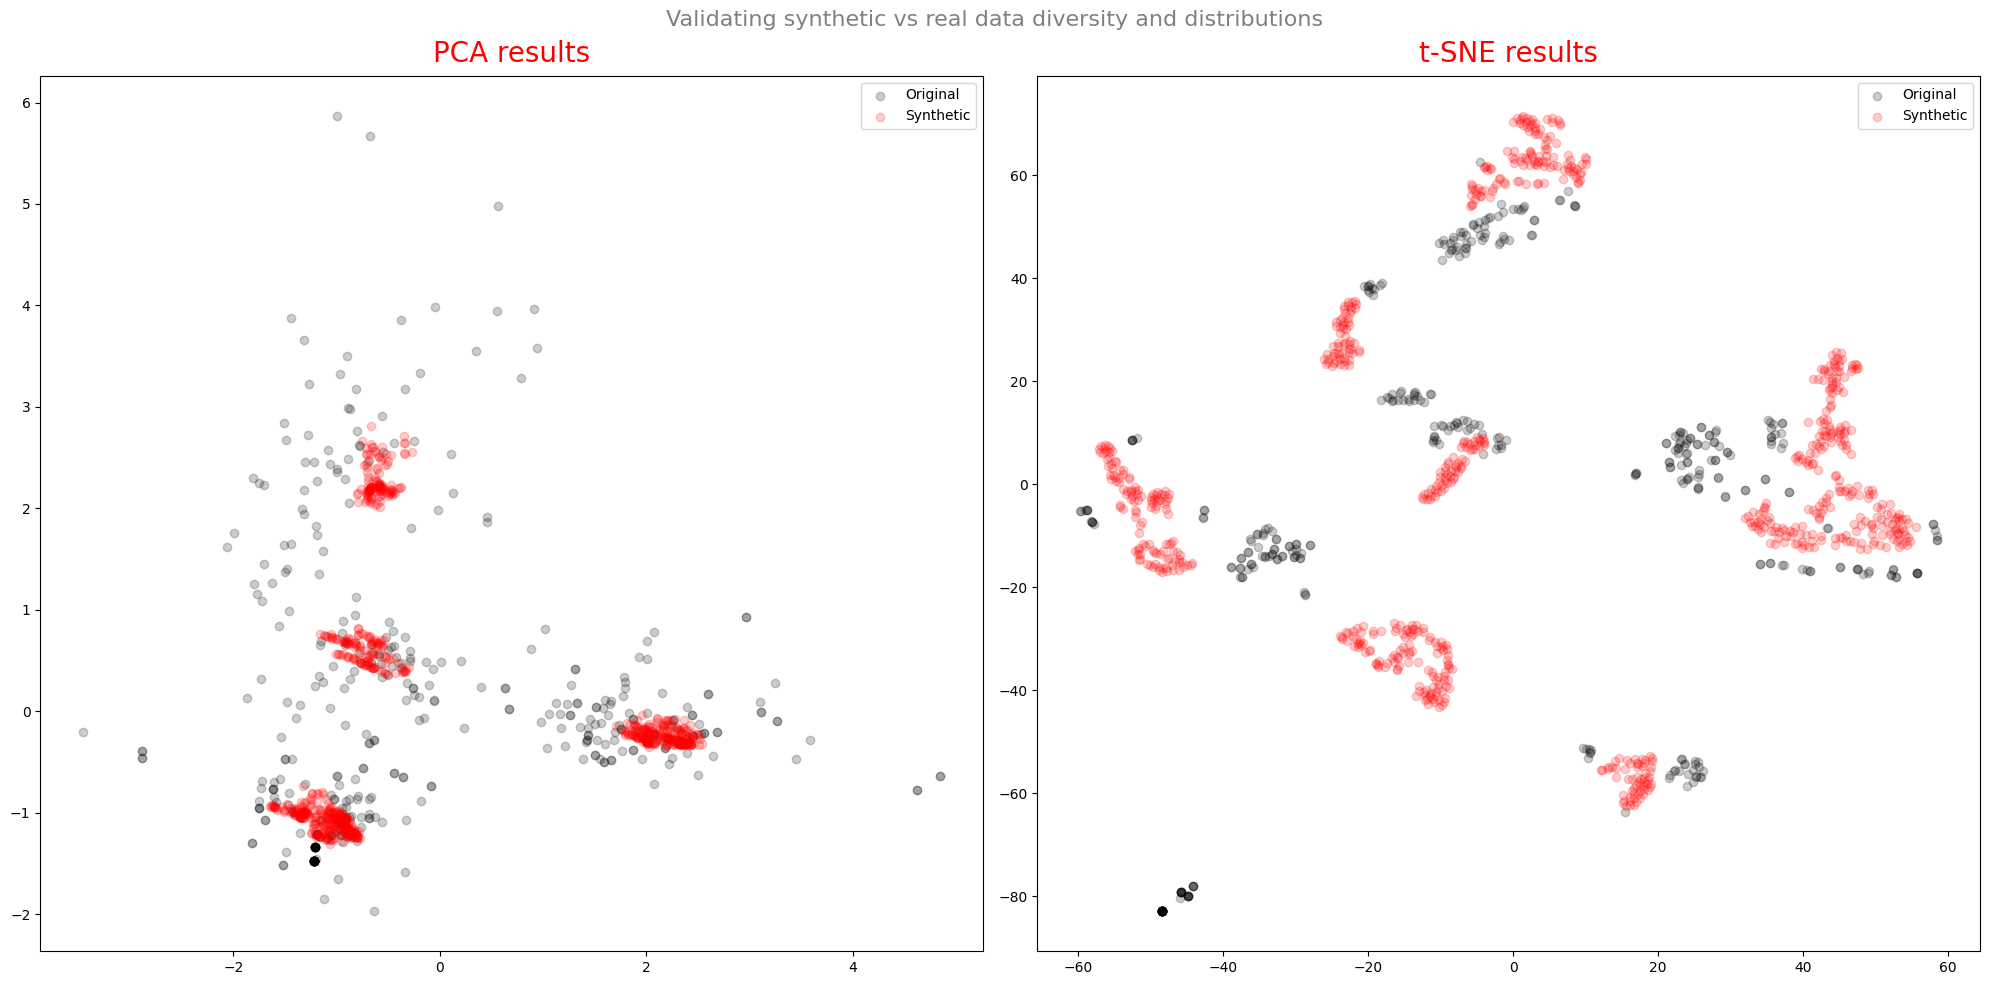

In [57]:
# Plotting
plt.figure(figsize=(20, 10))

# PCA plot
plt.subplot(1, 2, 1)
plt.scatter(pca_real[:, 0], pca_real[:, 1], c='black', alpha=0.2, label='Original')
plt.scatter(pca_synthetic[:, 0], pca_synthetic[:, 1], c='red', alpha=0.2, label='Synthetic')
plt.title('PCA results', fontsize=20, color='red', pad=10)
plt.legend()

# t-SNE plot
plt.subplot(1, 2, 2)
plt.scatter(tsne_real[:, 0], tsne_real[:, 1], c='black', alpha=0.2, label='Original')
plt.scatter(tsne_synthetic[:, 0], tsne_synthetic[:, 1], c='red', alpha=0.2, label='Synthetic')
plt.title('t-SNE results', fontsize=20, color='red', pad=10)
plt.legend()

plt.suptitle('Validating synthetic vs real data diversity and distributions', fontsize=16, color='grey')
plt.tight_layout()
plt.show()

In [58]:
# REAL DATA F1 Score

In [59]:
# import os
# import random
# import numpy as np
# import pandas as pd
# import tensorflow as tf
# from sklearn.preprocessing import StandardScaler
# from sklearn.utils import class_weight
# from sklearn.metrics import f1_score, classification_report
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import LSTM, Dropout, Dense

# # 1) Fix seeds for reproducibility
# os.environ['PYTHONHASHSEED'] = '42'
# random.seed(42)
# np.random.seed(42)
# tf.random.set_seed(42)

# # 2) Build LSTM model
# def build_model(input_shape):
#     m = Sequential([
#         LSTM(64, return_sequences=True, input_shape=input_shape),
#         Dropout(0.2),
#         LSTM(32),
#         Dropout(0.2),
#         Dense(1, activation='sigmoid')
#     ])
#     m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
#     return m

# # 3) Sequence builder
# def make_sequences(X, y, ids, time_steps=30):
#     Xs, ys, uids = [], [], []
#     for uid in np.unique(ids):
#         mask = (ids == uid)
#         Ud, Yd = X[mask], y[mask]
#         for i in range(len(Ud) - time_steps + 1):
#             Xs.append(Ud[i:i + time_steps])
#             ys.append(Yd[i + time_steps - 1])
#             uids.append(uid)
#     return np.array(Xs), np.array(ys), np.array(uids)

# # 4) Load & preprocess real training data (initial split)
# df_train = pd.read_csv('train_data_v1.csv')
# features = ['exact_computed','avg_ox_sat','rescue','controller','heart_rate','steps','calories']
# X_train_raw = df_train[features].values
# y_train_raw = df_train['exacerbation_event'].values
# ids_train_raw = df_train.id.values

# scaler = StandardScaler().fit(X_train_raw)
# X_train_scaled = scaler.transform(X_train_raw)

# X_real_seq, y_real_seq, user_ids_train = make_sequences(
#     X_train_scaled, y_train_raw, ids_train_raw
# )

# # 5) Load & preprocess real test data
# df_test = pd.read_csv('test_data_v1.csv')
# X_test_raw = df_test[features].values
# y_test_raw = df_test['exacerbation_event'].values
# ids_test_raw = df_test.id.values

# X_test_scaled = scaler.transform(X_test_raw)
# X_test_seq, y_test_seq, user_ids_test = make_sequences(
#     X_test_scaled, y_test_raw, ids_test_raw
# )

# # 6) Stage 1: train on real only
# model_real = build_model((X_real_seq.shape[1], X_real_seq.shape[2]))
# model_real.fit(
#     X_real_seq, y_real_seq,
#     epochs=50, batch_size=32,
#     shuffle=False,
#     verbose=2
# )
# # Evaluate real-only
# y_pred_real = (model_real.predict(X_test_seq) > 0.5).astype(int).flatten()
# f1_real = f1_score(y_test_seq, y_pred_real)
# print(f"\nBaseline F1 (real only): {f1_real:.4f}")
# print(classification_report(y_test_seq, y_pred_real))

# # 7) Load & prepare synthetic positives
# df_synth = pd.read_csv('synthetic_data_v1.csv')
# df_synth = df_synth[df_synth.exacerbation_event == 1]
# X_synth_raw = df_synth[features].values
# y_synth_raw = df_synth['exacerbation_event'].values
# ids_synth_raw = df_synth.id.values

# X_synth_scaled = scaler.transform(X_synth_raw)
# # calibrate to zero-mean/unit-variance
# means_s, stds_s = X_synth_scaled.mean(axis=0), X_synth_scaled.std(axis=0)
# X_synth_scaled = (X_synth_scaled - means_s) / stds_s

# X_synth_seq, y_synth_seq, user_ids_synth = make_sequences(
#     X_synth_scaled, y_synth_raw, ids_synth_raw
# )

# # 8) Combine real + synthetic for training
# X_comb = np.concatenate([X_real_seq, X_synth_seq], axis=0)
# y_comb = np.concatenate([y_real_seq, y_synth_seq], axis=0)
# user_ids_comb = np.concatenate([user_ids_train, user_ids_synth], axis=0)

# # compute class weights
# cw = class_weight.compute_class_weight(
#     'balanced', classes=np.unique(y_comb), y=y_comb
# )
# class_weights = dict(zip(np.unique(y_comb), cw))

# # 9) Stage 2: fine-tune on combined
# model_comb = build_model((X_real_seq.shape[1], X_real_seq.shape[2]))
# tf.keras.backend.set_value(model_comb.optimizer.learning_rate, 1e-4)
# model_comb.fit(
#     X_comb, y_comb,
#     epochs=50, batch_size=32,
#     shuffle=False,
#     class_weight=class_weights,
#     verbose=2
# )
# # Evaluate combined
# y_pred_comb = (model_comb.predict(X_test_seq) > 0.5).astype(int).flatten()
# f1_comb = f1_score(y_test_seq, y_pred_comb)
# print(f"\nF1 after real + synthetic: {f1_comb:.4f}")
# print(classification_report(y_test_seq, y_pred_comb))

# # 10) Save per-user .npy
# for uid in np.unique(user_ids_comb):
#     idx = np.where(user_ids_comb == uid)[0]
#     np.save(f'X_train_{uid}.npy', X_comb[idx])
#     np.save(f'y_train_{uid}.npy', y_comb[idx])
# for uid in np.unique(user_ids_test):
#     idx = np.where(user_ids_test == uid)[0]
#     np.save(f'X_test_{uid}.npy', X_test_seq[idx])
#     np.save(f'y_test_{uid}.npy', y_test_seq[idx])

# print("\nDone: models trained, F1s printed, .npy files saved.")


In [60]:
# LSTM F1 Score with REAL DATA on adjusting weights (prioritizing class 1 labels)

In [61]:

np.random.seed(42)

data_path = 'train_data_v1.csv'
df = pd.read_csv(data_path)

# Features and target
features = ['exact_computed', 'avg_ox_sat', 'rescue', 'controller', 'heart_rate', 'steps', 'calories']
X_train = df[features].values
y_train = df['exacerbation_event'].values

# Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

# Reshape data for LSTM: (users, time steps, features)
time_steps = 30
n_users = df.id.unique().__len__()  # 8 user test data from the csv file

# Creating a 3D array: (users, time_steps, features)
X_train_reshaped = []
y_train_reshaped = []

for user in df.id.unique():
    user_data = X_train[df['id'] == user]
    for i in range(len(user_data) - time_steps + 1):
        X_train_reshaped.append(user_data[i:i + time_steps])
        y_train_reshaped.append(y_train[i + time_steps - 1])  # Corresponding target

X_train = np.array(X_train_reshaped)
y_train = np.array(y_train_reshaped)




# Compute class weights for handling class imbalance
class_weights = {0: 1, 1: (len(y_train) * 29/ (2 * np.sum(y_train == 1)))}

# Step 2: Build the LSTM Model
model = Sequential()
model.add(L.LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(L.Dropout(0.2))
model.add(L.LSTM(32))
model.add(L.Dropout(0.2))
model.add(L.Dense(1, activation='sigmoid'))  # Binary classification

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Define early stopping callback to prevent overfitting
# early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model with class weights and early stopping
# model.fit(X_train, y_train, epochs=500, batch_size=32, validation_split=0.2, class_weight=class_weights, callbacks=[early_stopping])
model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, class_weight=class_weights) 
#model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2)


##TEST DATA PREP AND PREDICT

# Step 5: Predict on the test set and calculate F1 score
df = pd.read_csv('test_data_v1.csv')
X_test = df[features].values
y_test = df['exacerbation_event'].values

# Scale the features
scaler = StandardScaler()
X_test = scaler.fit_transform(X_test)

# Reshape data for LSTM: (users, time steps, features)
time_steps = 30
n_users = df.id.unique().__len__()  # 8 user test data from the csv file

# Creating a 3D array: (users, time_steps, features)
X_test_reshaped = []
y_test_reshaped = []

for user in df.id.unique():
    user_data = X_test[df['id'] == user]
    for i in range(len(user_data) - time_steps + 1):
        X_test_reshaped.append(user_data[i:i + time_steps])
        y_test_reshaped.append(y_test[i + time_steps - 1])  # Corresponding target

X_test = np.array(X_test_reshaped)
y_test = np.array(y_test_reshaped)

# Step 4: Evaluate the Model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Accuracy: {accuracy:.2f}')

y_test_pred_prob = model.predict(X_test)
y_test_pred = (y_test_pred_prob > 0.5).astype(int).flatten()

# Calculate F1 score
f1 = f1_score(y_test, y_test_pred)
print(f'F1 Score: {f1:.4f}')

# You can also print classification report for more detailed metrics
from sklearn.metrics import classification_report
print(classification_report(y_test, y_test_pred))

# Save the model
model.save('real_data_trained_lstm_model_v1.h5')
print("Model saved to 'trained_lstm_model_v1.h5'")

Epoch 1/100
4/4 [==============================] - 2s 163ms/step - loss: 9.7001 - accuracy: 0.3095 - val_loss: 0.6782 - val_accuracy: 0.9062
Epoch 2/100
4/4 [==============================] - 0s 17ms/step - loss: 8.9239 - accuracy: 0.2143 - val_loss: 0.7017 - val_accuracy: 0.3750
Epoch 3/100
4/4 [==============================] - 0s 41ms/step - loss: 8.0844 - accuracy: 0.1349 - val_loss: 0.7603 - val_accuracy: 0.0625
Epoch 4/100
4/4 [==============================] - 0s 23ms/step - loss: 6.9527 - accuracy: 0.0873 - val_loss: 0.8252 - val_accuracy: 0.0625
Epoch 5/100
4/4 [==============================] - 0s 19ms/step - loss: 5.9073 - accuracy: 0.0873 - val_loss: 0.8881 - val_accuracy: 0.0625
Epoch 6/100
4/4 [==============================] - 0s 17ms/step - loss: 5.4169 - accuracy: 0.0794 - val_loss: 0.9771 - val_accuracy: 0.0938
Epoch 7/100
4/4 [==============================] - 0s 15ms/step - loss: 4.7888 - accuracy: 0.0794 - val_loss: 1.0820 - val_accuracy: 0.0938
Epoch 8/100
4/4 [==

/Users/arshiakoul/miniconda3/envs/ai_env/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [62]:
# F1 score for real + synthetic data

In [4]:
# LSTM F1 Score with combined data (Real + Synthetic) - CODE 1 with 
# balanced classes - Timestep 30 days
np.random.seed(42)
tf.random.set_seed(42)

# Step 1: Load Real Data
data_path = 'train_data_v1.csv'
df = pd.read_csv(data_path)

# Features and target
features = ['exact_computed', 'avg_ox_sat', 'rescue', 'controller', 'heart_rate', 'steps', 'calories']
X_train = df[features].values
y_train = df['exacerbation_event'].values

# Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

# Reshape data for LSTM: (users, time steps, features)
time_steps = 30
n_users = df.id.unique().__len__()  # 8 user test data from the csv file

# Creating a 3D array: (users, time_steps, features)
X_train_reshaped = []
y_train_reshaped = []

for user in df.id.unique():
    user_data = X_train[df['id'] == user]
    for i in range(len(user_data) - time_steps + 1):
        X_train_reshaped.append(user_data[i:i + time_steps])
        y_train_reshaped.append(y_train[i + time_steps - 1])  # Corresponding target

X_train = np.array(X_train_reshaped)
y_train = np.array(y_train_reshaped)
print(X_train.shape)
print(y_train.shape)

# Step 5: Load and prepare synthetic data
synthetic_data_path = './synthetic_data_v1.csv'
synthetic_df = pd.read_csv(synthetic_data_path)
synthetic_df = synthetic_df[synthetic_df['exacerbation_event'] == 1]

# Ensure the same features are used
X_synthetic = synthetic_df[features].values
y_synthetic = synthetic_df['exacerbation_event'].values  # Predicted labels from the previous step

# Scale the synthetic data using the same scaler as real data
X_synthetic_scaled = scaler.transform(X_synthetic)

# Reshape synthetic data for LSTM
X_synthetic_reshaped = []

for user in synthetic_df['id'].unique():
    user_data = X_synthetic_scaled[synthetic_df['id'] == user]
    for i in range(len(user_data) - time_steps + 1):
        X_synthetic_reshaped.append(user_data[i:i + time_steps])

X_synthetic_reshaped = np.array(X_synthetic_reshaped)
y_synthetic_reshaped = np.array(y_synthetic[:len(X_synthetic_reshaped)])

# Step 6: Combine real training data with synthetic data for training
X_train = np.concatenate([X_train, X_synthetic_reshaped], axis=0)
y_train = np.concatenate([y_train, y_synthetic_reshaped], axis=0)

model = Sequential()
model.add(L.LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(L.Dropout(0.2))
model.add(L.LSTM(32))
model.add(L.Dropout(0.2))
model.add(L.Dense(1, activation='sigmoid'))  # Binary classification

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Define early stopping callback to prevent overfitting
# early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model with class weights and early stopping
model.fit(X_train, y_train, epochs=500, batch_size=32, validation_split=0.2, class_weight=class_weights)
#model.fit(X_train, y_train, epochs=500, batch_size=32, validation_split=0.2)

##TEST DATA PREP AND PREDICT

# Step 5: Predict on the test set and calculate F1 score
df = pd.read_csv('test_data_v1.csv')
X_test = df[features].values
y_test = df['exacerbation_event'].values

# Scale the features
scaler = StandardScaler()
X_test = scaler.fit_transform(X_test)

# Reshape data for LSTM: (users, time steps, features)
time_steps = 30
n_users = df.id.unique().__len__()  # 8 user test data from the csv file

# Creating a 3D array: (users, time_steps, features)
X_test_reshaped = []
y_test_reshaped = []

for user in df.id.unique():
    user_data = X_test[df['id'] == user]
    for i in range(len(user_data) - time_steps + 1):
        X_test_reshaped.append(user_data[i:i + time_steps])
        y_test_reshaped.append(y_test[i + time_steps - 1])  # Corresponding target

X_test = np.array(X_test_reshaped)
y_test = np.array(y_test_reshaped)

# Step 4: Evaluate the Model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Accuracy: {accuracy:.2f}')

# Step 5: Predict on the test set and calculate F1 score
y_test_pred_prob = model.predict(X_test)
y_test_pred = (y_test_pred_prob > 0.5).astype(int).flatten()

# Calculate F1 score
f1 = f1_score(y_test, y_test_pred)
print(f'F1 Score: {f1:.4f}')

# You can also print classification report for more detailed metrics
from sklearn.metrics import classification_report
print(classification_report(y_test, y_test_pred))
# Step 11: Save the trained model
model.save('combined_real_synthetic_lstm_model_v1.h5')

(158, 30, 7)
(158,)


NameError: name 'class_weights' is not defined

In [64]:
for user in synthetic_df['id'].unique():
    user_data = X_synthetic_scaled[synthetic_df['id'] == user]
    for i in range(len(user_data) - time_steps + 1):
        X_synthetic_reshaped.append(user_data[i:i + time_steps])
    print(X_synthetic_reshaped)
        

AttributeError: 'numpy.ndarray' object has no attribute 'append'

In [ ]:
# TODO : Please save the .npy files for xtrain /ytrain AND  xtest/ytest  for all users - real+Synthetic data. The filder has the ones in there please confirm you are creating similar files after the step above.